In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

In [9]:
model = load_model("../models/classification_model.keras", compile=False)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model loaded successfully ✅")

Model loaded successfully ✅


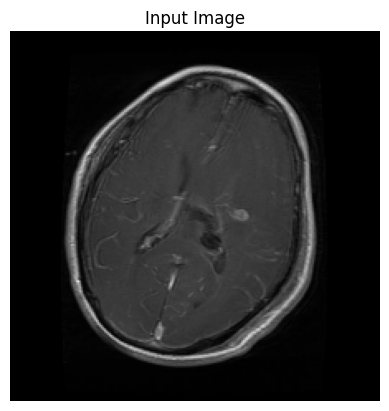

In [15]:
img_path = "../data/raw/Testing/glioma/Te-gl_10.jpg"

img = cv2.imread(img_path)

if img is None:
    print("❌ Image not found! Check path")
else:
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")

In [17]:
img_array = np.expand_dims(img, axis=0)
img_array = preprocess_input(img_array)

In [18]:
preds = model.predict(img_array)
class_idx = np.argmax(preds[0])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print("Predicted Class:", class_names[class_idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class: glioma


In [19]:
last_conv_layer = None

for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break

print("Last Conv Layer:", last_conv_layer)

Last Conv Layer: top_conv


In [21]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    # Create model that maps input → last conv layer + output
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Gradient calculation
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Compute gradients
    grads = tape.gradient(class_channel, conv_outputs)

    # Global average pooling
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight feature maps
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

(np.float64(-0.5), np.float64(6.5), np.float64(6.5), np.float64(-0.5))

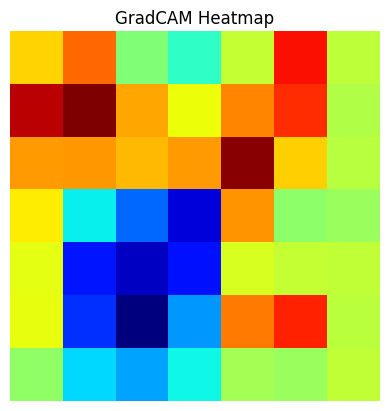

In [22]:
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer)

plt.imshow(heatmap, cmap='jet')
plt.title("GradCAM Heatmap")
plt.axis("off")

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

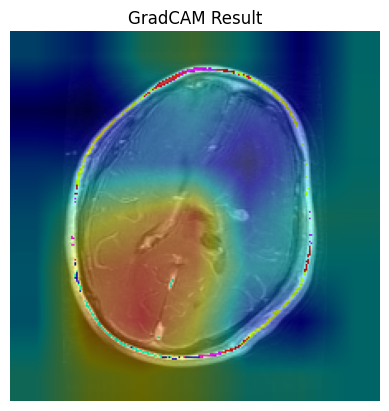

In [23]:
heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(superimposed_img.astype("uint8"))
plt.title("GradCAM Result")
plt.axis("off")

In [ ]:
d